# CHILI Case 1: Venus

In [2]:
import sys
sys.path.append('/home/maxime/Models/MOAI/src')

from physics import eos,viscosity
from physics.phase_change.refractories import mc_book
from chemistry.elements import *
from chemistry.molecules import *
from chemistry.equilibria import *
from chemistry.redox import *
from magma_ocean import magma_ocean # fractional_crystallization as magma_ocean
from atmospheres import multi_species_single_condensible_convective_atmosphere as atmosphere
from utils import y2s
import matplotlib.pyplot as plt

import exo_k as xk
xk.Settings().set_mks(True)
xk_datapath = '/home/maxime/Models/Radiative_Transfer/data/'

%matplotlib inline

eq_C.coefs[O2]      = 0
eq_H.coefs[O2]      = 0

## Inputs

In [3]:
Rp          = 6.3781e6 # planetary radius        [m]  from CHILI Protocol paper
Rc          = 0.55*Rp  # core radius                  [m]  from CHILI Protocol paper
g           = 9.81     # surface gravity              [m/s^2]
T0          = 3000.    # initialpotential temperature [K]
p_CMB       = 135e9    # CMB pressure                 [Pa]

from scipy.constants import Stefan_Boltzmann
semimajor_axis      = 1. # [AU]
Bond_albedo         = 0.1   # [-]     from CHILI Protocol paper
flux1AU             = 920. # [W/m^2] from CHILI Protocol paper
solar_zenith_angle  = 60/180*np.pi
stellar_irradiation = flux1AU/semimajor_axis**2/4/np.cos(solar_zenith_angle)
T_eq                = (stellar_irradiation*(1.-Bond_albedo)/Stefan_Boltzmann)**0.25

M_ini = {'H2O':4.2e21,'CO2':1e21}
# fO2: fina value should be IW+4. Final value? Or average (upper) mantle?

## Solar evolution
### Bolometric flux

In [4]:
log_star_age,log_relative_bolometric_luminosity = np.genfromtxt('../Sun_evol_BHAC2015.txt',skip_header=1,usecols=[1,3],unpack=True)

from scipy.interpolate import interp1d
get_relative_bolometric_luminosity = interp1d(10**log_star_age,10**log_relative_bolometric_luminosity)
solar_constant = 1334 # [W/m^2]
F_bol = lambda t_yr,a_AU: get_relative_bolometric_luminosity(t_yr)*solar_constant/a_AU**2

### XUV flux

In [5]:
# Zahnle et al., 2019
def F_XUV(t_yr,a_AU):
    F = 5*(4.5/(t_yr/1e9))**1.24 # [erg/cm^2/s]
    F_sat = 400 # [erg/cm^2/s]
    return np.minimum(F,F_sat)*1e-7*1e4/a_AU**2

(1000000.0, 100000000.0)

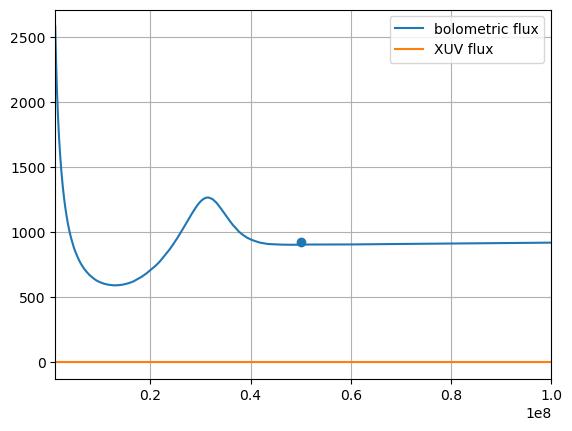

In [6]:
plt.plot(np.logspace(6,np.log10(4.5e9),1000),F_bol(np.logspace(6,np.log10(4.5e9),1000),1),label='bolometric flux')
plt.plot(np.logspace(6,np.log10(4.5e9),1000),F_XUV(np.logspace(6,np.log10(4.5e9),1000),1),label='XUV flux')
plt.scatter([50e6],[flux1AU])
plt.legend()
plt.grid()
plt.xlim(1e6,1e8)

## Model

### Thermal evolution model

In [7]:
# create MO
from physics.eos import eos_book
from physics.viscosity import eta_mixed_phase
N = 50
MO = magma_ocean(T0,
                 p_CMB,
                 eos={'rho':eos_book['rho']['MK19l'],
                      'alpha':eos_book['alpha']['N19'],
                      'cp':eos_book['cp']['cst'],
                      'kappa':lambda p,T:np.ones(N)*1e-6,
                      'eta':lambda p,T:eta_mixed_phase(p,T,mc_book['Earth'].getMeltFraction(p,T))},
                 g=g,
                 R=Rp,
                 ConvCum=True,
                 N=50)

# add melting curves
from physics.phase_change.refractories import mc_book
MO.setMeltingCurves(mc_book['Earth'],RCMF=0.4)
MO.updateT_pot(max(MO.T_pot_lookup))

No file found: calculating lookups, be patient it can take some time!


In [8]:
while MO.adiabat.getT(MO.p_CMB) < MO.mc.getTliq(MO.p_CMB):
    MO.updateT_pot(MO.adiabat.T_pot+1)
    #print(MO.adiabat.getT(MO.p_CMB),MO.mc.getTliq(MO.p_CMB))

### Redox model

In [9]:
# Set Fe3*/FeT in MO
from chemistry.partition_coefficients import get_part_coef
Fe_ferrous.part_coef = 1
MO.setParametrization('D_Fe3+_profile',lambda var: get_part_coef(var['pressures'],'Fe3+','2000km'),['pressures'],ptype='profile',channel='')

def set_Fe_ferric_part_coef(MO):
    # integrate the D_Fe3+ profile over
    Fe_ferric.part_coef = MO.getAverage(MO.profiles['D_Fe3+_profile'],domain=[MO.p_bot,MO.p_liq],mass_weighted=True)
    if np.isnan(Fe_ferric.part_coef):
        Fe_ferric.part_coef = get_part_coef(MO.p_bot,'Fe3+','2000km')
    return Fe_ferric.part_coef
MO.setParametrization('D_Fe3+_eff', lambda var: set_Fe_ferric_part_coef(var['MO']),[],ptype='scalar')

BSE_Fe3p_FeT = 0.094 # 0.17 # 0.094 is tuned to have IW-4 when the potential temperature is 1600 K (8.7% MO remaining). 0.17 is tuned to have IW-4 at 1600 K when the MO is 660 km-de8
BSE_FeO      = 0.0583 # Sun and McDonnough 1995
MO.addSpecies([Fe_ferric,Fe_ferrous],
              [BSE_Fe3p_FeT*BSE_FeO,(1-BSE_Fe3p_FeT)*BSE_FeO])
MO.to_frac=['Fe3+','Fe2+']
MO.fractionation(MO.to_frac)
MO.setParametrization('Fe3+/FeT',lambda var:1/(1+1/(var['Fe3+_liquid']/var['Fe2+_liquid']*Fe_ferrous.molecular_mass/Fe_ferric.molecular_mass)),
                      ['Fe2+_liquid','Fe3+_liquid'],ptype='scalar')

# Set fO2
from physics.constants import BSE
MO.setParametrization('fO2_sfc',
                      lambda var: fO2_sfc_H22(var['T_pot'],var['Fe3+/FeT'],BSE),
                      ['T_pot','Fe3+/FeT'],
                      ptype='scalar')
from chemistry.redox import fO2_buffers_H22
MO.setParametrization('DeltaIW_sfc',
                      lambda var: np.log10(var['fO2_sfc'])-fO2_buffers_H22(var['p_sfc'],var['T_pot']),
                      ['T_pot','p_sfc','fO2_sfc'],
                      ptype='scalar')

/home/maxime/Models/MOAI/src/magma_ocean.py:894: RuntimeWarning: invalid value encountered in scalar divide
  return self.getIntegral(profile*self.profiles['rho'],domain=domain) / self.getIntegral(self.profiles['rho'],domain=domain)


### Chemical model

In [10]:
MO.setupChemistry({H2O:M_ini['H2O']/MO.M_system,
                   CO2:M_ini['CO2']/MO.M_system,
                   N2:1e-6,
                   S2:1e-6})
MO.speciationInit()

### Atmosphere

In [11]:
MO.atm = atmosphere(list(MO.atm.species.values()),
                    np.array([MO.atm.partial_pressure[sp.formula] for sp in list(MO.atm.species.values())]),
                    MO.adiabat.T_pot,R=MO.R_out,g=MO.gravity,pToA=1,cond=H2O,T_str=200.)

In [12]:
MO.t = 50e6*y2s
def update_T_eq(t,atm):
    T_eq = (F_bol(t/y2s,semimajor_axis)/4/np.cos(solar_zenith_angle)*(1.-Bond_albedo)/Stefan_Boltzmann)**0.25
    MO.atm.T_eq = T_eq
MO.setParametrization('T_eq',lambda var:update_T_eq(var['t'],var['atm']),['t','atm'],channel='post-spec',ptype='action')

In [13]:
xk.Settings().add_search_path(xk_datapath + 'corrk',path_type='ktable')
corrk_database = xk.Kdatabase(['H2O','CO2','CO','NH3','CH4','H2S','HCN','SO2'])

R=10
wavenumber_grid=xk.wavenumber_grid_R(200.,10000.,R)
corrk_database.bin_down(wavenumber_grid)

xk.Settings().add_search_path(xk_datapath + 'cia',path_type='cia')
cia_database = xk.CIAdatabase(molecules=['H2'])
cia_database.sample(corrk_database.wns)

In [14]:
R = sum([8.314/(molecules_book[sp].molecular_mass/1000)*MO.atm.volume_mixing_ratio[sp] for sp in MO.atm.species])
cp = sum([molecules_book[sp].cp_mass(MO.atm.Ts)*MO.atm.volume_mixing_ratio[sp] for sp in MO.atm.species])
rcp = R/cp

logplay = np.log10(np.flipud(MO.atm.profiles['pressure']))
tlay    = np.flipud(MO.atm.profiles['temperature'])
clay    = {sp:np.flipud(MO.atm.profiles['molar fraction'][sp]) for sp in MO.atm.species}

MO.atm.radiation = xk.Atm(logplay=logplay,
                          tlay=tlay,
                          grav=MO.gravity, Rp=MO.R_out, rcp=rcp,
                          albedo_surf=Bond_albedo,
                          composition=clay,
                          k_database=corrk_database,
                          cia_database=cia_database,
                          rayleigh=True)
def getOLR():
    return MO.atm.radiation.emission_spectrum_2stream().total

MO.atm.getOLR = getOLR

In [15]:
def update_rad_pres(var):
    MO.atm.radiation.set_logPT_profile(np.log10(np.flipud(var['atm'].profiles['pressure'])),np.flipud(var['atm'].profiles['temperature']))
MO.setParametrization('radPres',update_rad_pres,['atm'],is_profile=False,channel='post-spec',ptype='action')  

/home/maxime/Models/MOAI/src/magma_ocean.py:894: RuntimeWarning: invalid value encountered in scalar divide
  return self.getIntegral(profile*self.profiles['rho'],domain=domain) / self.getIntegral(self.profiles['rho'],domain=domain)


### Escape

In [16]:
from scipy.constants import N_A
def atmospheric_escape(f_H2,dt,t,MO):
    t_yr = t/y2s
    S = F_XUV(t_yr,semimajor_axis)/F_XUV(4.5e9,semimajor_axis)
    phi_H2 = 2e16*f_H2*S/np.sqrt(1+0.006*S**2)/N_A # [mol/m^2/s] (valid for f_H2 < 0.2)
    MO.content['system']['H'] -= 4*np.pi*MO.R_out**2*phi_H2*dt*(2*H.atomic_mass)/MO.M_system
    return phi_H2
MO.setParametrization('f_H2',lambda var:var['atm'].profiles['molar fraction']['H2'][-1],['atm'],is_profile=False,channel='post-spec',ptype='scalar')
MO.setParametrization('phi_H2',lambda var:atmospheric_escape(var['f_H2'],var['dt'],var['t'],var['MO']),['f_H2','t','dt'],is_profile=False,channel='time-dep',ptype='scalar')

In [17]:
def flux_residual(MO,T):
    #print('Calculating flux residual for T_surf=',T)
    MO.atm.updateTs(T)
    MO.updateBL(MO.adiabat.T_pot-T)
    # now need to update composition (can be altered by condensation) and tempreature profiles
    MO.atm.radiation.set_gas({sp:np.flipud(MO.atm.profiles['molar fraction'][sp]) for sp in MO.atm.species})
    MO.atm.radiation.set_T_profile(np.flipud(MO.atm.profiles['temperature']))
    return MO.BL.getFlux()+MO.atm.getASR()-MO.atm.getOLR()
MO.flux_residual = flux_residual

In [18]:
MO.atm.stellar_irradiation = stellar_irradiation
MO.RK4_step(0)

/home/maxime/Models/MOAI/src/magma_ocean.py:894: RuntimeWarning: invalid value encountered in scalar divide
  return self.getIntegral(profile*self.profiles['rho'],domain=domain) / self.getIntegral(self.profiles['rho'],domain=domain)


0

## Outputs

In [19]:
from tools import time_series
ts=time_series(MO)

# Add custom quantities
ts.register('OLR','atm.getOLR()')                          # Save OLR
ts.register('mu_atm','atm.average_molecular_mass')         # Save average molecular mass of the atmosphere
ts.register('p_tot','atm.ps')                              # Save surface pressure
ts.register('p_cloud','atm.cloud_deck')                    # Save lifting condensation level
ts.register('T_bot','adiabat.getT(self.attribute.p_bot)')  # Save temperature at the bottom of the MO
ts.register('Ra','getRa(\'MO\')')                          # Save MO Rayleigh number
ts.register('phi_H2','scalar[\'phi_H2\']')                 # Save MO Rayleigh number
ts.register('Fconv','BL.getFlux()')
ts.register('T_eq','atm.T_eq')
ts.register('T_surf','atm.Ts')
#ts.register('T_pot','')
#ts.register('F_surf','')
#ts.register('OLR','')
#ts.register('ASR','')
ts.register('avg_melt_frac','averages[\'phi\']')
#ts.register('fO2','')
#ts.register('d_TBL','')
#ts.register('m_C','')
#ts.register('m_H','')
#ts.register('m_O','')
#ts.register('p_surf','')
ts.register('p_H2O','atm.partial_pressure[\'H2O\']')
#ts.register('p_H2','')
#ts.register('p_CO2','')
#ts.register('p_CO','')
#ts.register('p_CH4','')
#ts.register('p_O2','')
#ts.register('mean_molecular_weight','')
#ts.register('R_trans','')
#ts.register('R_sol','')
#ts.register('viscosity','')

ts.write(0)

In [20]:
MO.max_dT=100000*y2s
dt = 10*y2s
#dt /= 2

MO.max_change['Tpot']= 5
MO.min_T_surf = 1000

In [21]:
while MO.M_system/ts('M_sys')[0] > 0.01:
    dt=MO.RK4_step(dt,rtol=0.001)
    ts.write(MO.t)
    print('M/M0=',MO.M_system/ts('M_sys')[0])
    print('Tpot=',MO.adiabat.T_pot,'K')
    print('dt=',dt/y2s,'y')

M/M0= 1.0
Tpot= 2968.4456994311513 K
dt= 20.0 y
M/M0= 1.0
Tpot= 2967.925858996934 K
dt= 40.0 y
M/M0= 1.0
Tpot= 2966.886936779667 K
dt= 80.0 y
M/M0= 1.0
Tpot= 2964.812109878468 K
dt= 160.0 y
M/M0= 1.0
Tpot= 2960.674552624779 K
dt= 193.35079878031001 y
M/M0= 1.0
Tpot= 2955.704000656233 K
dt= 194.4963054443867 y
M/M0= 1.0
Tpot= 2950.739683140608 K
dt= 195.89430453655675 y
M/M0= 1.0
Tpot= 2945.7755869357934 K
dt= 197.31114834817035 y
M/M0= 1.0
Tpot= 2940.8122115984006 K
dt= 198.76710397224824 y
M/M0= 1.0
Tpot= 2935.849006662396 K
dt= 200.24067768219473 y
M/M0= 1.0
Tpot= 2930.886397687498 K
dt= 201.74940106611686 y
M/M0= 1.0
Tpot= 2925.9240182633694 K
dt= 203.27889488371756 y
M/M0= 1.0
Tpot= 2920.9622067273176 K
dt= 204.84342604179756 y
M/M0= 1.0
Tpot= 2916.000414490266 K
dt= 206.42080145168595 y
M/M0= 1.0
Tpot= 2911.0390721199274 K
dt= 208.02918448622023 y
M/M0= 1.0
Tpot= 2906.0780808426766 K
dt= 209.6649367639073 y
M/M0= 1.0
Tpot= 2901.1171161617776 K
dt= 211.3146839879471 y
M/M0= 1.0
Tpo

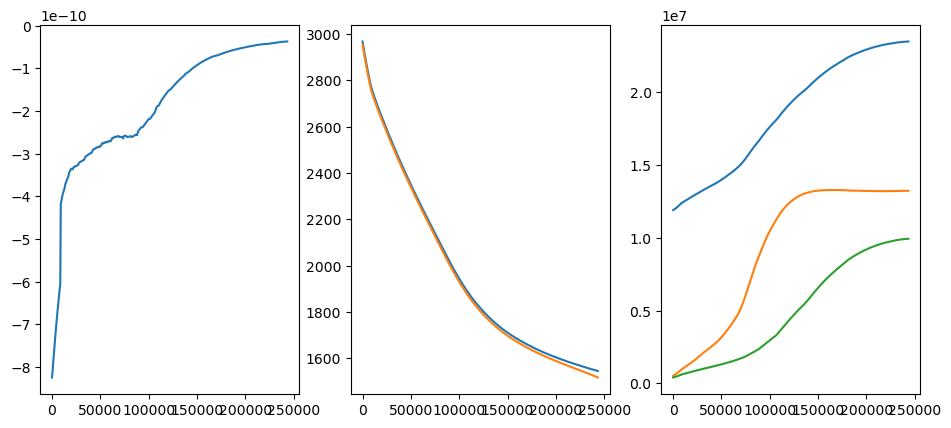

In [22]:
plt.subplot(131)
plt.plot(ts('time')[1:]/y2s-50e6,np.gradient(ts('T_pot')[1:],ts('time')[1:]))
#plt.plot(ts2('time')/y2s,np.gradient(ts2('T_pot'),ts2('time')))
#plt.plot(ts3('time')/y2s,np.gradient(ts3('T_pot'),ts3('time')))

plt.subplot(132)
plt.plot(ts('time')[1:]/y2s-50e6,ts('T_pot')[1:])
plt.plot(ts('time')[1:]/y2s-50e6,ts('T_surf')[1:])
#plt.plot(ts2('time')/y2s,ts2('T_pot'))
#plt.plot(ts3('time')/y2s,ts3('T_pot'))

plt.subplot(133)
plt.plot(ts('time')[1:]/y2s-50e6,ts('p_tot')[1:])
plt.plot(ts('time')[1:]/y2s-50e6,ts('p_CO2')[1:])
plt.plot(ts('time')[1:]/y2s-50e6,ts('p_H2O')[1:])

plt.subplots_adjust(right=1.5)

In [23]:
M_atm = 4*np.pi*MO.R_out**2/MO.gravity*sum([ts('p_'+str(sp)) for sp in MO.atm.species])

In [24]:
M_H_atm = M_atm*(ts('p_H2O')/ts('p_tot')*H2O.molecular_mass/ts('mu_atm')*2*H.atomic_mass/H2O.molecular_mass \
               + ts('p_H2')/ts('p_tot')*H2.molecular_mass/ts('mu_atm')*2*H.atomic_mass/H2.molecular_mass \
               + ts('p_CH4')/ts('p_tot')*CH4.molecular_mass/ts('mu_atm')*4*H.atomic_mass/CH4.molecular_mass)
M_C_atm = M_atm*(ts('p_CO2')/ts('p_tot')*CO2.molecular_mass/ts('mu_atm')*C.atomic_mass/CO2.molecular_mass \
               + ts('p_CO')/ts('p_tot')*CO.molecular_mass/ts('mu_atm')*C.atomic_mass/CO.molecular_mass \
               + ts('p_CH4')/ts('p_tot')*CH4.molecular_mass/ts('mu_atm')*C.atomic_mass/CH4.molecular_mass)

In [25]:
M_H_cum = np.cumsum(np.append(0,-np.diff(ts('M_sys')))*(MO.mc.RCMF*ts('H_liquid')+(1-MO.mc.RCMF)*ts('H_solid')))
M_C_cum = np.cumsum(np.append(0,-np.diff(ts('M_sys')))*(MO.mc.RCMF*ts('C_liquid')+(1-MO.mc.RCMF)*ts('C_solid')))

In [26]:
import pandas as pd
ts_pd = pd.DataFrame({'t(yr)':ts('t')/y2s,
                      'T_surf(K)':ts('T_pot'),
                      'T_pot(K)':ts('T_sfc'),
                      'flux_surf(W/m2)':ts('Fconv'),
                      'flux_OLR(W/m2)':ts('OLR'),
                      'flux_ASR(W/m2)':np.ones_like(ts('t'))*stellar_irradiation,
                      'phi(vol_frac)':ts('phi_avg'),
                     #'fO2_solid(bar)':[],
                      'fO2_melt(bar)':ts('fO2_sfc'),
                     #'thick_surf_bl(m)':[],
                      'massC_solid(kg)':M_C_cum,
                      'massC_melt(kg)':ts('C_system')*ts('M_sys')-M_C_atm,
                      'massC_atm(kg)':M_C_atm,
                      'massH_solid(kg)':M_H_cum,
                      'massH_melt(kg)':ts('H_system')*ts('M_sys')-M_H_atm,
                      'massH_atm(kg)':M_H_atm,
                      'p_surf(bar)':ts('p_tot')*1e-5,
                      'p_H2O(bar)':ts('p_H2O')*1e-5,
                      'p_CO2(bar)':ts('p_CO2')*1e-5,
                      'p_CO(bar)':ts('p_CO')*1e-5,
                      'p_H2(bar)':ts('p_H2')*1e-5,
                      'p_CH4(bar)':ts('p_CH4')*1e-5,
                      'p_O2(bar)':ts('fO2_sfc'),
                      'mmw(kg/mol)':ts('mu_atm')*1e-3,
                      'viscosity(Pa.s)':ts('viscosity_avg'),
                      'R_solid(m)':MO.R_out-MO.LE.getz(ts('p_bot'))})
ts_pd.to_csv('evolution-moai-earth-escape.csv')

In [26]:
(ts_pd['massC_atm(kg)']+ts_pd['massC_solid(kg)']+ts_pd['massC_melt(kg)'])

0      2.727273e+20
1      2.727273e+20
2      2.727273e+20
3      2.727273e+20
4      2.727273e+20
           ...     
291    2.727844e+20
292    2.727844e+20
293    2.727844e+20
294    2.727844e+20
295    2.727844e+20
Length: 296, dtype: float64

In [47]:
import exo_k as xk
xk.util.spectrum.Spectrum(np.array([1e-1,1e-2]),np.array([0.01,0.1]))


        value        : [0.1  0.01]
        wl (microns) : [1000000.  100000.]
        

In [ ]:
import pandas as pd
ds = pd.DataFrame({'t(yr)':ts('time')/y2s,'T_surf(K)':ts('T_surf'),'phi(vol_frac)':ts('phi_avg'),'p_H2O(bar)':ts('p_H2O')*1e-5})

In [ ]:
#ds.to_csv('CHILI_protocol_paper_Earth_MOAI.csv',index_label=False)

In [ ]:
import pandas as pd
ds = pd.read_csv('CHILI_protocol_paper_Earth_MOAI.csv')

In [ ]:
np.savetxt('/home/maxime/Projects/FOREVER/test_Earth.ts',np.array([MO.LE.getz(ts('p_bot')[14:])/MO.LE.getz(MO.p_CMB),(ts('time')[14:]-ts('time')[14])/((MO.LE.getz(MO.p_CMB))**2/1e-6)]).T)

In [ ]:
import pandas as pd
ds = pd.DataFrame({'t(yr)':ts('time')/y2s,'T_surf(K)':ts('T_surf'),'phi(vol_frac)':ts('phi_avg'),'p_H2O(bar)':ts('p_H2O')*1e-5})

,t(yr),T_surf(K),phi(vol_frac),p_H2O(bar)
0,0.000000,2985.000000,1.000000,4.187957
1,1.000000,2984.926153,1.000000,4.187974
2,3.000000,2984.778470,1.000000,4.188010
3,7.000000,2984.483147,1.000000,4.188080
4,15.000000,2983.892676,1.000000,4.188221
...,...,...,...,...
295,121200.691463,1548.961213,0.021044,156.968788
296,123523.373787,1542.986789,0.020145,157.927752
297,125866.284439,1536.793447,0.019256,158.845228
298,128257.452048,1530.303860,0.018367,159.645224
